# 第2周 b｜描述性统计与可视化

学习目标：均值、标准差、中位数、四分位距、类别比例。

> **本周怎么学**：先学精讲 `w02a_descriptive.ipynb`，再做这份**工程实践**。

__数据：默认使用官方 PRIME-CVD 5 万人数据__（`python run.py download` 下载，来源与 MD5 核验记录在 `data/raw/manifest.json`）。把 `MODE` 改成 `"demo"` 可以切换到离线演示数据，但演示数据是另外生成的，**不是 PRIME-CVD**，结果不能当作官方结果。

本周验收：提交基线表和三张图，每张写两句话。

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display

# 从项目根目录、notebooks目录或其他项目内目录启动均可。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请在解压后的项目目录中启动 Jupyter。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from primecvd.common import load_config, provenance_label
from primecvd.pipeline import prepare
from primecvd.splitting import select_split

MODE = "official"  # 官方数据；离线练习或跑测试时可改为 "demo"（演示数据不是 PRIME-CVD）
cfg = load_config(ROOT / "configs" / f"{MODE}.json")
cfg["output_dir"] = f"outputs/notebooks_{MODE}"
print(provenance_label(cfg))
df, splits = prepare(cfg)
train = select_split(df, splits, "train")
valid = select_split(df, splits, "valid")
# 不创建test DataFrame；模型试验只使用train和valid。
print("队列、训练集、验证集：", len(df), len(train), len(valid))

# 命令行绘图模块采用无窗口后端；在Notebook中显式启用行内图像。
get_ipython().run_line_magic("matplotlib", "inline")
from primecvd import pubplot as pp   # 与精讲篇相同的顶刊作图风格（在启用行内图像之后设置）
pp.setup()

OFFICIAL SOURCE FILES / 官方下载文件
队列、训练集、验证集： 50000 35000 7500


## 基线表：先学清楚分布
只使用训练集进行建模前的分布探索。连续变量的均值/标准差和中位数/四分位距回答不同问题，偏态分布尤其值得比较。

In [2]:
from primecvd.pipeline import training_summary
display(training_summary(train))

,variable,n,summary
0,Age,35000,mean 49.774; SD 12.345; median 49.658; IQR 41....
1,BMI,35000,mean 28.345; SD 5.037; median 28.340; IQR 24.9...
2,HbA1c,35000,mean 4.784; SD 0.932; median 4.656; IQR 4.236–...
3,eGFR,35000,mean 82.749; SD 6.088; median 82.937; IQR 79.1...
4,SBP,35000,mean 123.420; SD 16.064; median 123.245; IQR 1...
5,diabetes=0,32400,92.57%
6,diabetes=1,2600,7.43%
7,CKD=0,34770,99.34%
8,CKD=1,230,0.66%
9,AF=0,34747,99.28%


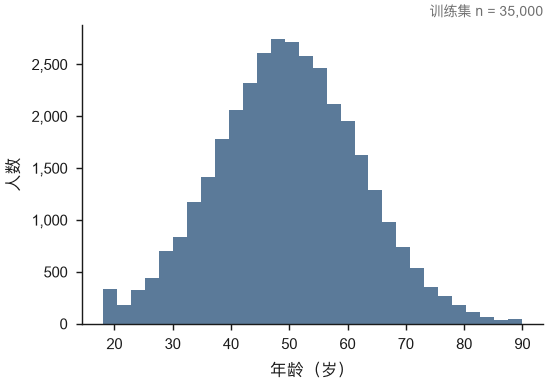

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=pp.size(pp.SINGLE, 58))
ax.hist(train.Age, bins=30, color=pp.NEUTRAL, lw=0)
ax.set(xlabel="年龄（岁）", ylabel="人数")
ax.text(1, 1.02, f"训练集 n = {len(train):,}", transform=ax.transAxes, ha="right", va="bottom",
        fontsize=6, color=pp.GREY)
pp.thousands_axis(ax)
plt.show()

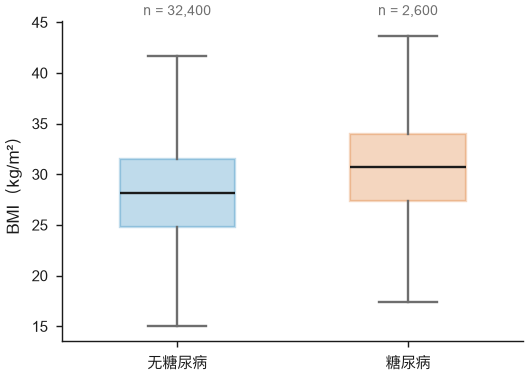

smoking_status,current,ex,non
diabetes,,,
0,0.102,0.166,0.731
1,0.099,0.170,0.731


In [4]:
fig, ax = plt.subplots(figsize=pp.size(pp.SINGLE, 62))
groups = [train.loc[train.diabetes.eq(k), "BMI"] for k in (0, 1)]
# 样本量很大时须线外的点会有上千个，糊成一片，这里不画离群点（showfliers=False），分布范围见上面的基线表
box = ax.boxplot(groups, tick_labels=["无糖尿病", "糖尿病"], widths=0.5, patch_artist=True, showfliers=False,
                 medianprops=dict(color=pp.INK, lw=1), whiskerprops=dict(color=pp.GREY),
                 capprops=dict(color=pp.GREY))
for patch, color in zip(box["boxes"], [pp.REFERENCE, pp.EXPOSED]):   # 参照组蓝、暴露组朱红
    patch.set(facecolor=color, alpha=0.25, edgecolor=color)
for i, g in enumerate(groups, 1):
    ax.text(i, 1.01, f"n = {len(g):,}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=6, color=pp.GREY)
ax.set_ylabel("BMI（kg/m²）")
plt.show()
display(pd.crosstab(train.diabetes, train.smoking_status, normalize="index").round(3))

## 独立练习
另做一张吸烟类别条形图。给每张图写两句话：第一句描述观察，第二句说明不能据此推断什么。不要给基线表每一行机械添加p值，合成数据里的比例也不能当作真实流行病学数据。

---
本周复盘：请用自己的话记录一个学会的概念、一个发现的错误和一个待解决问题。

特别提醒：优先描述，不给基线表每行机械添加显著性检验。